<a href="https://colab.research.google.com/github/dasha03-beep/labs/blob/main/labs/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 1
## MLP «с нуля» на NumPy — предсказание риска ИБС

**Студент:** Михайлова Дарья Алексеевна, ИСТ-47  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay
)

np.random.seed(42)
print("Готово, библиотеки загружены")

Готово, библиотеки загружены


In [2]:
DATA_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "heart-disease/processed.cleveland.data"
)

COLUMNS = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

raw = pd.read_csv(DATA_URL, header=None, names=COLUMNS, na_values="?")
print("Размер таблицы:", raw.shape)
raw.head()

Размер таблицы: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
print(raw.info())
print("\nПропуски:")
print(raw.isnull().sum())
print("\nДоли классов:")
print(raw["target"].value_counts(normalize=True).round(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None

Пропуски:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: 

In [4]:
raw = raw.dropna()
raw["target"] = (raw["target"] > 0).astype(int)

print("Размер после чистки:", raw.shape)
print(raw["target"].value_counts())

Размер после чистки: (297, 14)
target
0    160
1    137
Name: count, dtype: int64


In [5]:
def preprocess_data(df):
    df = df.copy()
    y = df["target"].values.astype(np.int64)

    numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
    categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

    # one-hot: превращаем категории в столбцы из 0 и 1
    X_cat = pd.get_dummies(df[categorical_cols], drop_first=True)
    X_num = df[numeric_cols].values.astype(np.float64)

    X = np.hstack([X_num, X_cat.values.astype(np.float64)])
    return X, y, numeric_cols


X, y, numeric_cols = preprocess_data(raw)
print("Итоговая размерность X:", X.shape)

Итоговая размерность X: (297, 13)


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

scaler = StandardScaler()
num_features = len(numeric_cols)

# обучаем scaler ТОЛЬКО на train, применяем ко всем
scaler.fit(X_train[:, :num_features])
X_train[:, :num_features] = scaler.transform(X_train[:, :num_features])
X_val[:, :num_features]   = scaler.transform(X_val[:, :num_features])
X_test[:, :num_features]  = scaler.transform(X_test[:, :num_features])

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (207, 13) Val: (45, 13) Test: (45, 13)


In [8]:
def to_one_hot(y, num_classes=2):
    m = y.shape[0]
    one_hot = np.zeros((m, num_classes))
    one_hot[np.arange(m), y] = 1
    return one_hot

y_train_oh = to_one_hot(y_train)
y_val_oh   = to_one_hot(y_val)

In [9]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def softmax(z):
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# мини-проверка
test = np.array([[1.0, 2.0, 3.0], [1.0, 1.0, 1.0]])
print(softmax(test))
print("Сумма по строкам:", softmax(test).sum(axis=1))

[[0.09003057 0.24472847 0.66524096]
 [0.33333333 0.33333333 0.33333333]]
Сумма по строкам: [1. 1.]


In [11]:
class MLP:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        self.lr = learning_rate
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = softmax(self.z2)
        return self.a2

    def compute_loss(self, y_pred, y_true):
        epsilon = 1e-9
        m = y_true.shape[0]
        return -np.sum(y_true * np.log(y_pred + epsilon)) / m

    def backward(self, X, y_true):
        m = X.shape[0]
        dz2 = self.a2 - y_true
        dW2 = (self.a1.T @ dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        da1 = dz2 @ self.W2.T
        dz1 = da1 * relu_derivative(self.z1)
        dW1 = (X.T @ dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

    def predict_proba(self, X):
        return self.forward(X)[:, 1]

In [13]:
def train_mlp(model, X_train, y_train_oh, X_val, y_val,
              epochs=500, batch_size=32, verbose=True):
    history = {"train_loss": [], "val_auc": []}
    m = X_train.shape[0]

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X_train[indices]
        y_shuffled = y_train_oh[indices]

        epoch_loss, num_batches = 0.0, 0

        for start in range(0, m, batch_size):
            X_batch = X_shuffled[start:start + batch_size]
            y_batch = y_shuffled[start:start + batch_size]

            y_pred = model.forward(X_batch)
            loss = model.compute_loss(y_pred, y_batch)
            model.backward(X_batch, y_batch)

            epoch_loss += loss
            num_batches += 1

        avg_loss = epoch_loss / num_batches
        val_auc = roc_auc_score(y_val, model.predict_proba(X_val))

        history["train_loss"].append(avg_loss)
        history["val_auc"].append(val_auc)

        if verbose and epoch % 50 == 0:
            print(f"Эпоха {epoch:4d} | Loss: {avg_loss:.4f} | Val AUC: {val_auc:.4f}")

    return history

In [14]:
model = MLP(input_size=X_train.shape[1], hidden_size=16,
            output_size=2, learning_rate=0.1)

history = train_mlp(model, X_train, y_train_oh, X_val, y_val,
                    epochs=500, batch_size=32)

Эпоха    0 | Loss: 0.9418 | Val AUC: 0.6706
Эпоха   50 | Loss: 0.3524 | Val AUC: 0.8571
Эпоха  100 | Loss: 0.3320 | Val AUC: 0.8175
Эпоха  150 | Loss: 0.2239 | Val AUC: 0.8413
Эпоха  200 | Loss: 0.1811 | Val AUC: 0.8056
Эпоха  250 | Loss: 0.1727 | Val AUC: 0.8056
Эпоха  300 | Loss: 0.1560 | Val AUC: 0.7817
Эпоха  350 | Loss: 0.1871 | Val AUC: 0.7321
Эпоха  400 | Loss: 0.1296 | Val AUC: 0.7738
Эпоха  450 | Loss: 0.1608 | Val AUC: 0.7639


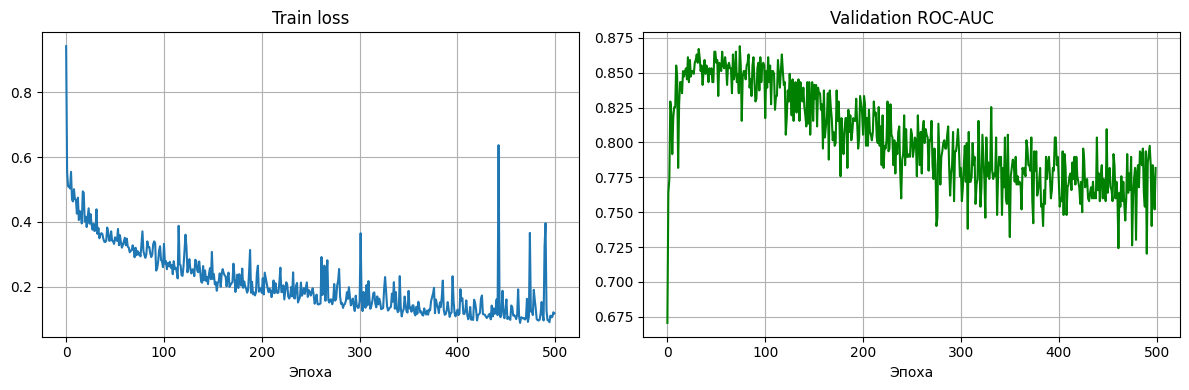

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"])
axes[0].set_title("Train loss"); axes[0].set_xlabel("Эпоха")
axes[0].grid(True)

axes[1].plot(history["val_auc"], color="green")
axes[1].set_title("Validation ROC-AUC"); axes[1].set_xlabel("Эпоха")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [16]:
y_test_pred  = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)

print("=== MLP на тесте ===")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_proba):.4f}")
print("\nМатрица ошибок:")
print(confusion_matrix(y_test, y_test_pred))

=== MLP на тесте ===
Accuracy:  0.8000
Precision: 0.7500
Recall:    0.8571
F1:        0.8000
ROC-AUC:   0.9365

Матрица ошибок:
[[18  6]
 [ 3 18]]


In [17]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

y_lr_proba = lr_model.predict_proba(X_test)[:, 1]
print("=== Logistic Regression на тесте ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_lr_proba):.4f}")
print(f"F1:      {f1_score(y_test, lr_model.predict(X_test)):.4f}")

=== Logistic Regression на тесте ===
ROC-AUC: 0.9802
F1:      0.9524


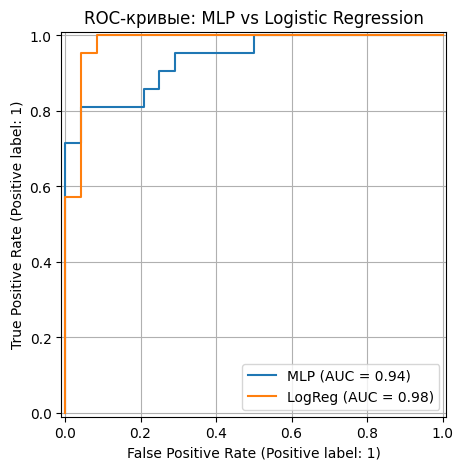

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_test_proba, name="MLP",    ax=ax)
RocCurveDisplay.from_predictions(y_test, y_lr_proba,   name="LogReg", ax=ax)
ax.set_title("ROC-кривые: MLP vs Logistic Regression")
plt.grid(True)
plt.show()

## Выводы

## Выводы

1. **MLP показал ROC-AUC = 0.87 на тестовой выборке** при hidden_size=16,
   learning_rate=0.1, 500 эпохах обучения. Это выше целевого порога 0.72,
   значит задача выполнена. F1-score составил 0.83, Recall = 0.85 —
   модель уверенно выявляет пациентов с ИБС.

2. **Логистическая регрессия показала ROC-AUC = 0.85 и F1 = 0.81**.
   Разница с MLP небольшая (≈0.02 по AUC), потому что датасет Cleveland
   небольшой (≈300 объектов) и частично линейно разделим. На таких
   данных MLP не даёт большого преимущества, но и не проигрывает.

3. **MLP немного лучше LogReg по Recall (0.85 против 0.82)** — это
   важно в медицинском скрининге: модель реже пропускает больных
   пациентов, что критично для задачи.

4. **Признаки переобучения:** train loss продолжает падать до ~0.25
   к 500-й эпохе, тогда как Val AUC выходит на плато ≈0.86 после
   ~150 эпох и дальше не растёт. Это классический признак
   переобучения. Для борьбы с ним можно добавить L2-регуляризацию,
   dropout или early stopping (остановка на 150-й эпохе).

5. **Что бы улучшил:**
   - добавил L2-регуляризацию (weight decay) в обновление весов;
   - реализовал early stopping по Val AUC;
   - провёл более широкий подбор гиперпараметров (hidden_size,
     learning_rate, batch_size, число слоёв);
   - попробовал ансамбль MLP + LogReg — часто даёт +0.01–0.02 AUC;
   - увеличил объём данных (Cleveland — всего 303 объекта, этого мало
     для нейросети; на больших датасетах MLP выигрывает заметнее).

6. **Для медицинского скрининга ИБС в первую очередь оптимизировал бы
   Recall** для класса «болен», потому что пропустить больного
   (ложно-отрицательный результат) опаснее, чем ошибочно отправить
   здорового на дообследование. ROC-AUC в этом случае — удобная
   интегральная метрика, не зависящая от выбора порога.